In [78]:
#Importamos todas las librerias a utilizar en el trabajo (faltan)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo 
import category_encoders as ce
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import roc_curve, auc, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, make_scorer,classification_report, roc_auc_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau 
from tensorflow.keras.optimizers import Adam
from sklearn.compose import make_column_transformer
from sklearn.model_selection import GridSearchCV, StratifiedKFold,  cross_val_predict
from sklearn.pipeline import Pipeline

In [79]:
#Importamos el dataset
bank_marketing = fetch_ucirepo(id=222) 

#Transformamos en DataFrame las features y los targets
X = bank_marketing.data.features 
y = bank_marketing.data.targets 

In [52]:
#Creamos un data frame unificado
df = pd.concat([X,y],axis=1)
print(f'El dataset tiene: {df.shape[0]} filas, y {df.shape[1]} columnas')
df.head()

El dataset tiene: 45211 filas, y 17 columnas


,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no


In [80]:
#Vemos los tipos de datos de cada feature
X.info() 

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   age          45211 non-null  int64
 1   job          44923 non-null  str  
 2   marital      45211 non-null  str  
 3   education    43354 non-null  str  
 4   default      45211 non-null  str  
 5   balance      45211 non-null  int64
 6   housing      45211 non-null  str  
 7   loan         45211 non-null  str  
 8   contact      32191 non-null  str  
 9   day_of_week  45211 non-null  int64
 10  month        45211 non-null  str  
 11  duration     45211 non-null  int64
 12  campaign     45211 non-null  int64
 13  pdays        45211 non-null  int64
 14  previous     45211 non-null  int64
 15  poutcome     8252 non-null   str  
dtypes: int64(7), str(9)
memory usage: 5.5 MB


In [81]:
# Binarizar y convertir 'y' en una Serie 1D
y = (y['y'] == 'yes').astype(int) 

# Verificar los resultados
print(y.value_counts())

y
0    39922
1     5289
Name: count, dtype: int64


In [82]:
#Vemos los valores nulos en X
print(X.isnull().sum())

#Vemos si y tiene valores nulos
print(y.isnull().sum())


age                0
job              288
marital            0
education       1857
default            0
balance            0
housing            0
loan               0
contact        13020
day_of_week        0
month              0
duration           0
campaign           0
pdays              0
previous           0
poutcome       36959
dtype: int64
0


In [83]:
#Reemplazamos los valores nulos por un valor 'unknown'
X = X.fillna('unknown')

#Vemos si nos quedaron valores nulos
X.isnull().sum()

age            0
job            0
marital        0
education      0
default        0
balance        0
housing        0
loan           0
contact        0
day_of_week    0
month          0
duration       0
campaign       0
pdays          0
previous       0
poutcome       0
dtype: int64

In [84]:
#Vemos qué valores únicos tiene cada feature
for col in X:
    print(f'{col} - unique: {X[col].nunique()}')

age - unique: 77
job - unique: 12
marital - unique: 3
education - unique: 4
default - unique: 2
balance - unique: 7168
housing - unique: 2
loan - unique: 2
contact - unique: 3
day_of_week - unique: 31
month - unique: 12
duration - unique: 1573
campaign - unique: 48
pdays - unique: 559
previous - unique: 41
poutcome - unique: 4


In [85]:
#Vemos si hay registros duplicados
X.duplicated().any()

np.False_

y
0    88.3
1    11.7
Name: proportion, dtype: float64


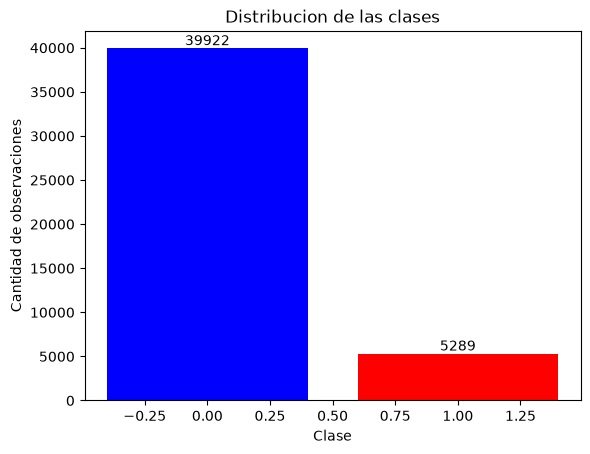

In [86]:
#Vemos la distribución de las clases

print(round(y.value_counts(normalize=True)*100,2))

class_counts = y.value_counts()
plt.bar(class_counts.index, class_counts.values, color = ['blue','red'])
plt.xlabel('Clase')
plt.ylabel('Cantidad de observaciones')
plt.title('Distribucion de las clases')

for clase, cantidad in class_counts.items():
    plt.text(clase, cantidad, str(cantidad), ha="center", va="bottom")

plt.show()


### PARTICIÓN Y TRANSFORMACIÓN DE DATOS

In [87]:

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# Luego dividimos el 'resto' en Dev (10%) y Test (10%)
X_dev, X_test, y_dev, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"Datos de Entrenamiento (Train): {X_train.shape}")
print(f"Datos de Desarrollo (Dev): {X_dev.shape}")
print(f"Datos de Prueba (Test): {X_test.shape}")

Datos de Entrenamiento (Train): (36168, 16)
Datos de Desarrollo (Dev): (4521, 16)
Datos de Prueba (Test): (4522, 16)


In [88]:
#Definimos las variables categóricas y numéricas 
categorical_columns = X.select_dtypes(include='str').columns
categorical_columns

numerical_columns = X.select_dtypes(include=('float','int')).columns
numerical_columns

Index(['age', 'balance', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous'],
      dtype='str')

In [89]:
#Creamos los transformadores
OneHot_Encoder = OneHotEncoder(drop='first',handle_unknown='error',sparse_output=False)
Scaler = StandardScaler()

Transformer = make_column_transformer(
    (OneHot_Encoder, categorical_columns),
    (Scaler, numerical_columns),
    remainder='passthrough'
    
)

In [90]:
#Transformamos las variables
X_train_transformed = Transformer.fit_transform(X_train)
X_dev_transformed = Transformer.transform(X_dev)
X_test_transformed = Transformer.transform(X_test)

### Creamos modelo baseline: una regresión logística

In [102]:
modelo_base = LogisticRegression(C=6,penalty='l2', max_iter=1000, verbose=3)
modelo_base.fit(X_train_transformed, y_train)


/Users/Camila/Desktop/TrabajoIA/BankMarketingClasificacion_IA/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",6
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"verbose verbose: int, default=0For the liblinear and lbfgs solvers set verbose to any positivenumber for verbosity.",3
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None


In [103]:
# 4. Evaluación en el conjunto de Desarrollo (Dev)
y_pred_dev = modelo_base.predict(X_dev_transformed)

# Cálculos de Métricas
matriz_conf = confusion_matrix(y_dev, y_pred_dev)
exactitud = accuracy_score(y_dev, y_pred_dev)
precision = precision_score(y_dev, y_pred_dev)
recall = recall_score(y_dev, y_pred_dev)
f1 = f1_score(y_dev, y_pred_dev) 

print("\n--- RESULTADOS EN EL CONJUNTO DEV ---")
print("Matriz de Confusión:")
print(matriz_conf)
print(f"Exactitud (Accuracy): {exactitud:.4f}")
print(f"Precisión:            {precision:.4f}")
print(f"Exhaustividad (Recall):{recall:.4f}")
print(f"Puntaje F1 (F1-Score): {f1:.4f}")


--- RESULTADOS EN EL CONJUNTO DEV ---
Matriz de Confusión:
[[3884  108]
 [ 344  185]]
Exactitud (Accuracy): 0.9000
Precisión:            0.6314
Exhaustividad (Recall):0.3497
Puntaje F1 (F1-Score): 0.4501


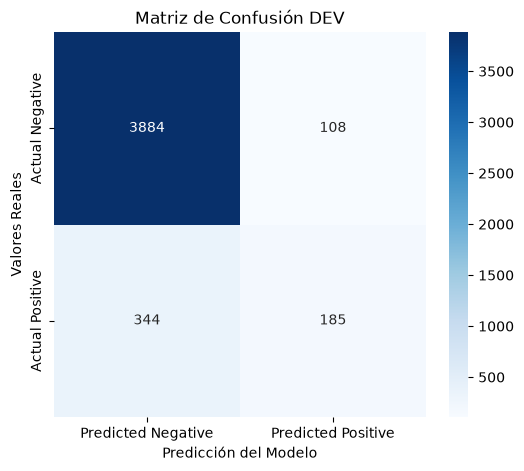

In [104]:
# Crear un mapa de calor de la matriz de confusión
plt.figure(figsize=(6, 5))
sns.heatmap(matriz_conf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.xlabel('Predicción del Modelo')
plt.ylabel('Valores Reales')
plt.title('Matriz de Confusión DEV')
plt.show()

In [105]:
# 4. Evaluación en el conjunto de Testeo (Test)
y_pred_test = modelo_base.predict(X_test_transformed)

# Cálculos de Métricas
matriz_conf = confusion_matrix(y_test, y_pred_test)
exactitud = accuracy_score(y_test, y_pred_test)
precision = precision_score(y_test, y_pred_test)
recall = recall_score(y_test, y_pred_test)
f1 = f1_score(y_test, y_pred_test) 

print("\n--- RESULTADOS EN EL CONJUNTO TEST ---")
print("Matriz de Confusión:")
print(matriz_conf)
print(f"Exactitud (Accuracy): {exactitud:.4f}")
print(f"Precisión:            {precision:.4f}")
print(f"Exhaustividad (Recall):{recall:.4f}")
print(f"Puntaje F1 (F1-Score): {f1:.4f} ")


--- RESULTADOS EN EL CONJUNTO TEST ---
Matriz de Confusión:
[[3900   93]
 [ 347  182]]
Exactitud (Accuracy): 0.9027
Precisión:            0.6618
Exhaustividad (Recall):0.3440
Puntaje F1 (F1-Score): 0.4527 


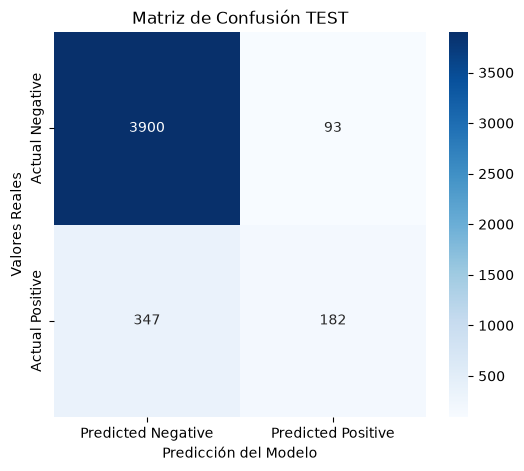

In [106]:
# Crear un mapa de calor de la matriz de confusión
plt.figure(figsize=(6, 5))
sns.heatmap(matriz_conf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.xlabel('Predicción del Modelo')
plt.ylabel('Valores Reales')
plt.title('Matriz de Confusión TEST')
plt.show()

In [110]:
pipeline2 = Pipeline([
    ('preprocesador', Transformer),
    ('modelo', modelo_base)
])

pipeline2.fit(X_train, y_train)

predicciones2 = pipeline2.predict(X_dev)
print(classification_report(y_dev,predicciones2))

              precision    recall  f1-score   support

           0       0.92      0.97      0.95      3992
           1       0.63      0.35      0.45       529

    accuracy                           0.90      4521
   macro avg       0.78      0.66      0.70      4521
weighted avg       0.89      0.90      0.89      4521



/Users/Camila/Desktop/TrabajoIA/BankMarketingClasificacion_IA/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


In [111]:
metricas = {
    "roc_auc": "roc_auc",
    "recall": "recall",
    "precision": "precision",
    "f1": "f1",
    "average_precision": "average_precision"
}

param_grid = {"modelo__C" : [0.01, 0.06, 0.07 ,0.08, 0.1, 0.2, 0.3, 0.5, 0.7, 0.8, 0.9, 1,1.5, 2,2.5, 3, 4 , 5, 6, 7, 8]}

cv = StratifiedKFold( n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=pipeline2,
    param_grid=param_grid,
    scoring=metricas,
    refit="recall", #avarage precision
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"Mejor valor de C: {grid_search.best_params_}")

print(f"Mejor recall promedio en validación cruzada: {grid_search.best_score_}")

Fitting 5 folds for each of 21 candidates, totalling 105 fits


/Users/Camila/Desktop/TrabajoIA/BankMarketingClasificacion_IA/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/Camila/Desktop/TrabajoIA/BankMarketingClasificacion_IA/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=n

Mejor valor de C: {'modelo__C': 6}
Mejor recall promedio en validación cruzada: 0.34555000125599744


/Users/Camila/Desktop/TrabajoIA/BankMarketingClasificacion_IA/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


/Users/Camila/Desktop/TrabajoIA/BankMarketingClasificacion_IA/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/Camila/Desktop/TrabajoIA/BankMarketingClasificacion_IA/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=n

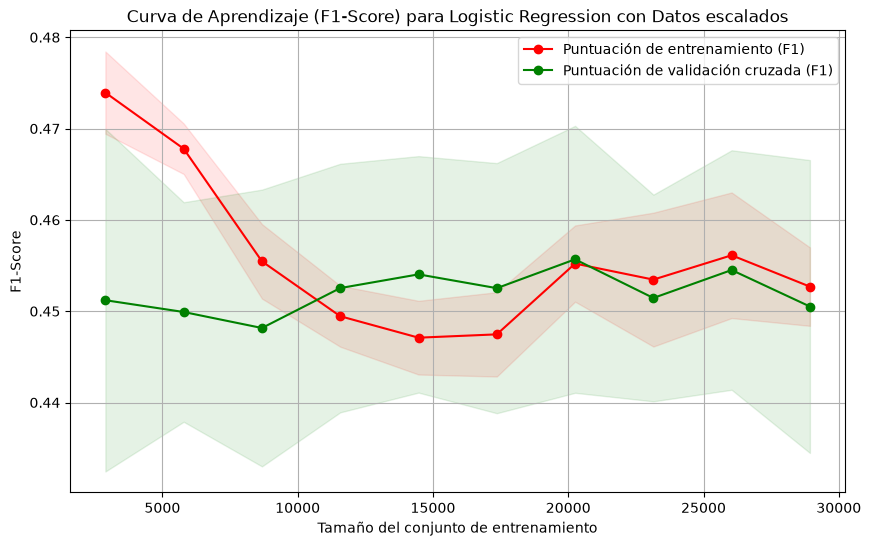

In [74]:
# Definir el scorer para F1-score
f1_scorer = make_scorer(f1_score)

# Generar la curva de aprendizaje con los datos de entrenamiento sin escalar
train_sizes, train_scores, test_scores = learning_curve(
    modelo_base, X_train_transformed, y_train, cv=5, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10), scoring=f1_scorer
)

# Calcular medias y desviaciones estándar
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

# Plotear la curva de aprendizaje
plt.figure(figsize=(10, 6))
plt.title("Curva de Aprendizaje (F1-Score) para Logistic Regression con Datos escalados")
plt.xlabel("Tamaño del conjunto de entrenamiento")
plt.ylabel("F1-Score")
plt.grid()

plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.1,
                 color="r")
plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                 test_scores_mean + test_scores_std, alpha=0.1,
                 color="g")
plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
         label="Puntuación de entrenamiento (F1)")
plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
         label="Puntuación de validación cruzada (F1)")

plt.legend(loc="best")
plt.show()

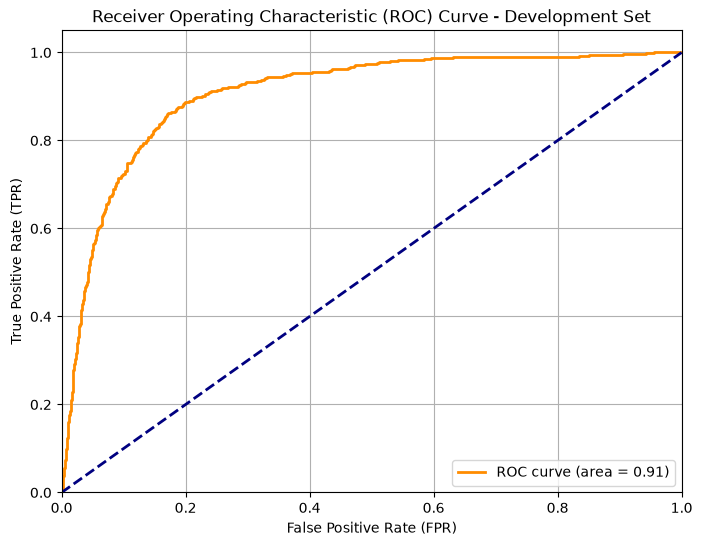

In [109]:
# Obtener las probabilidades de predicción para la clase positiva en el conjunto de desarrollo
y_pred_proba_dev = modelo_base.predict_proba(X_dev_transformed)[:, 1]

# Calcular la curva ROC
fpr, tpr, thresholds = roc_curve(y_dev, y_pred_proba_dev)
roc_auc = auc(fpr, tpr)

# Plotear la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve - Development Set')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()